# Custom Tirex Training

In [1]:
import os
import sys
#sys.path.append('../tirex/src') # Add the path to the tirex module

# set cuda home for compiling custom cuda kernel
os.environ["CUDA_HOME"] = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.3"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9" #see https://developer.nvidia.com/cuda-gpus
os.environ["XLSTM_EXTRA_INCLUDE_PATHS"] = r"C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v13.3/include"

msvc_bin = r"C:\Program Files\Microsoft Visual Studio\18\Community\VC\Tools\MSVC\14.51.36231\bin\Hostx64\x64"
if os.path.exists(msvc_bin):
    os.environ["PATH"] = msvc_bin + os.pathsep + os.environ["PATH"]
else:
    print(f"Warning: Could not find MSVC path at {msvc_bin}. Please check your version folder.")

os.environ["TORCH_EXTENSIONS_DIR"] = r"C:\py_venv\pw_tirex\torch_extensions"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from datetime import datetime
from pathlib import Path

from tirex_loss.models.base_model import Base_Model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)
# set default seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [3]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"

data_train = pl.read_csv(data_path_train, try_parse_dates=True)
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series_train = len(data_train['series_index'].unique())
number_series_test = len(data_test['series_index'].unique())

print(f"Number of time series in the train set: {number_series_train} | Length of the train set: {len(data_train)}")
print(f"Number of time series in the test set: {number_series_test} | Length of the test set: {len(data_test)}")
data_test.head()

Number of time series in the train set: 361 | Length of the train set: 20266216
Number of time series in the test set: 361 | Length of the test set: 5066729


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


In [4]:
# reduce amount of data
amount_train = 0.10
amount_test = 0.10

series_idx_train = data_train['series_index'].unique()
number_series_train = len(series_idx_train)
number_series_train_final = int(number_series_train * amount_train)
data_train_sampled = data_train.filter(pl.col('series_index').is_in(series_idx_train.sample(number_series_train_final).implode()))

series_idx_test = data_test['series_index'].unique()
number_series_test = len(series_idx_test)
number_series_test_final = int(number_series_test * amount_test)
data_test_sampled = data_test.filter(pl.col('series_index').is_in(series_idx_test.sample(number_series_test_final).implode()))

print(f"Training on {number_series_train_final} out of {number_series_train} series.")
print(f"Testing on {number_series_test_final} out of {number_series_test} series.")

Training on 36 out of 361 series.
Testing on 36 out of 361 series.


## Fine-Tuning Data

In [5]:
data_path_fets = "../data/data_fets.csv"
data_fets = pl.read_csv(data_path_fets, try_parse_dates=True)
data_fets

timestamp,value,series_index
"datetime[μs, UTC]",f64,i64
2019-12-31 23:00:00 UTC,43881.8,0
2019-12-31 23:15:00 UTC,43639.6,0
2019-12-31 23:30:00 UTC,43330.9,0
2019-12-31 23:45:00 UTC,43149.5,0
2020-01-01 00:00:00 UTC,43017.3,0
…,…,…
2025-10-13 20:45:00 UTC,51524.0,0
2025-10-13 21:00:00 UTC,50427.2,0
2025-10-13 21:15:00 UTC,49845.8,0


# Load Model

In [6]:
# use custom model
model = Base_Model(context_length=1024,
                   quantiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                   patch_size=32,
                   use_slstm=True)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model device: {device}")

Total Parameters: 1,610,816
Model device: cuda


# Dataloader

Dataloader produces sequences of length $n$ for the input and target sequences with random predictions lengths in the range of $s_{\min}$ and $s_{\max}$.

In [7]:
from tirex_loss.dataloader import (build_dataloader,
                                   build_dataloader_fixed,
                                   build_dataloader_from_dataset,
                                   TirexDataset, TirexDataset_Fixed)
from tirex_loss.dataloader.utils import create_windows, create_windows_fixed

In [8]:
n = model.context_length
patch_size=model.patch_size
s_min = 32
s_max = int(model.context_length / 2)
batch_size = 64
mode="shift"
cmax_mask=5
pmax_mask=0.25
cpm_stride=32

dataloader_train_shift = build_dataloader_fixed(data_train_sampled,
                                    context_length=n,
                                    s_min=s_min,
                                    s_max=s_max,
                                    mode="shift",
                                    patch_size=patch_size,
                                    cmax_mask=cmax_mask,
                                    pmax_mask=pmax_mask,
                                    cpm_stride=cpm_stride,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    num_workers=0,
                                    pin_memory=True
                                    )
dataloader_test_shift = build_dataloader_fixed(data_test_sampled,
                                   context_length=n,
                                   s_min=s_min,
                                   s_max=s_max,
                                   mode="shift",
                                   patch_size=patch_size,
                                   cmax_mask=cmax_mask,
                                   pmax_mask=pmax_mask,
                                   cpm_stride=cpm_stride,                                   
                                   batch_size=batch_size,
                                   shuffle=False,
                                   num_workers=0,
                                   pin_memory=True
                                   )

dataloader_train_cpm = build_dataloader_fixed(data_train_sampled,
                                    context_length=n,
                                    s_min=s_min,
                                    s_max=s_max,
                                    mode="cpm",
                                    patch_size=patch_size,
                                    cmax_mask=cmax_mask,
                                    pmax_mask=pmax_mask,
                                    cpm_stride=cpm_stride,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    num_workers=0,
                                    pin_memory=True
                                    )
dataloader_test_cpm = build_dataloader_fixed(data_test_sampled,
                                   context_length=n,
                                   s_min=s_min,
                                   s_max=s_max,
                                   mode="cpm",
                                   patch_size=patch_size,
                                   cmax_mask=cmax_mask,
                                   pmax_mask=pmax_mask,
                                   cpm_stride=cpm_stride,                                   
                                   batch_size=batch_size,
                                   shuffle=False,
                                   num_workers=0,
                                   pin_memory=True
                                   )

print(len(dataloader_train_shift), len(dataloader_test_shift))
print(len(dataloader_train_cpm), len(dataloader_test_cpm))

1114 212
1120 216


## Fine-Tuning data

In [9]:
n = model.context_length
s_min = 32
s_max = 128
batch_size = 64
train_ratio = 0.8

data_sets_filtered = data_fets
seq, lengths = create_windows_fixed(data_sets_filtered, n=n, s_min=s_min, s_max=s_max)

idx = np.random.permutation(len(seq))
seq, lengths = seq[idx], lengths[idx]

split = int(len(seq) * train_ratio)
seq_train, seq_test = seq[:split], seq[split:]
lengths_train, lengths_test = lengths[:split], lengths[split:]

dataset_train = TirexDataset_Fixed(sequences=seq_train,
                             prediction_lengths=lengths_train,
                             context_length=n,
                             prediction_length_min=s_min,
                             prediction_length_max=s_max
                             )
dataset_test = TirexDataset_Fixed(sequences=seq_test,
                            prediction_lengths=lengths_test,
                            context_length=n,
                            prediction_length_min=s_min,
                            prediction_length_max=s_max
                            )

dataloader_train_shift = build_dataloader_from_dataset(dataset_train,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    num_workers=0,
                                    pin_memory=True
                                    )
dataloader_test_shift = build_dataloader_from_dataset(dataset_test,
                                   batch_size=batch_size,
                                   shuffle=False,
                                   num_workers=0,
                                   pin_memory=True
                                   )

len(dataloader_train_shift), len(dataloader_test_shift)

(78, 19)

# Training / Fine-Tuning

we inspect different loss functions on autoreggresive or nan extension method and slstm and xlstm

In [10]:
from tirex_loss.training.tirex_trainer import Tirex_Trainer
from tirex_loss.loss import QuantileLoss, LossTypes

In [11]:
training_variants = {
    # quantile loss
    'custom_tirex_shift_slstm_quantile': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': QuantileLoss,
                                            'quantiles': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_shift_lstm_quantile': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': QuantileLoss,
                                            'quantiles': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_cpm_slstm_quantile': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': QuantileLoss,
                                            'quantiles': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                                            'dataloader': 'cpm'
                                            },
    'custom_tirex_cpm_lstm_quantile': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': QuantileLoss,
                                            'quantiles': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                                            'dataloader': 'cpm'
                                            },

    # mse loss
    'custom_tirex_shift_slstm_mse': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': LossTypes.MSE.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_shift_lstm_mse': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': LossTypes.MSE.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_cpm_slstm_mse': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': LossTypes.MSE.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'cpm'
                                            },
    'custom_tirex_cpm_lstm_mse': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': LossTypes.MSE.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'cpm'
                                            },

    # l1 loss
    'custom_tirex_shift_slstm_l1': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': LossTypes.L1.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_shift_lstm_l1': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': LossTypes.L1.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'shift'
                                            },
    'custom_tirex_cpm_slstm_l1': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': LossTypes.L1.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'cpm'
                                            },
    'custom_tirex_cpm_lstm_l1': {'Autoregressive': False,
                                            'use_slstm': False,
                                            'loss': LossTypes.L1.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'cpm'
                                            },                                        
}

In [12]:
# debugging tirex not learning on mse with slstm layer
training_variants = {
    # mse loss
    'custom_tirex_original_slstm_mse': {'Autoregressive': False,
                                            'use_slstm': True,
                                            'loss': LossTypes.MSE.value,
                                            'quantiles': [0.5],
                                            'dataloader': 'shift'
                                            },
}

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/78 [00:00<?, ?it/s]

step 0: loss=109701392.0000, grad_norm=1357812893.1480, max_grad=62948720.0000
step 50: loss=74236440.0000, grad_norm=307823371.8737, max_grad=13659789.0000


Batches Test:   0%|          | 0/19 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/78 [00:00<?, ?it/s]

...

step 0: loss=3644735.5000, grad_norm=140791916.1496, max_grad=21247886.0000
step 50: loss=2285729.2500, grad_norm=86142389.8556, max_grad=10886243.0000


Batches Test:   0%|          | 0/19 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/78 [00:00<?, ?it/s]

step 0: loss=2789270.5000, grad_norm=219286667.3845, max_grad=22137434.0000
step 50: loss=2347641.0000, grad_norm=145725873.8539, max_grad=10871514.0000


Batches Test:   0%|          | 0/19 [00:00<?, ?it/s]

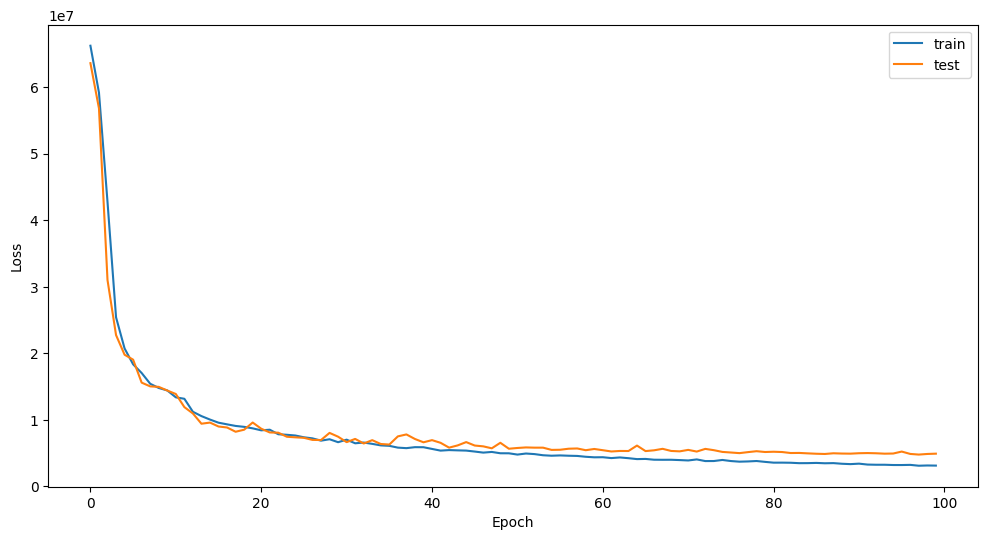

In [13]:
# Hyperparameters
epochs = 100
early_stop_patience = 100
lr = 1e-4
weight_decay = 0.01
use_gradient_clipping = True
clipping_max_norm = 1.0
context_length = 1024
patch_size = 32

for k, v in training_variants.items():
    quantiles = v['quantiles']
    autoregressive = v['Autoregressive']
    use_slstm = v['use_slstm']
    if v['dataloader'] == 'shift':
        dataloader_train = dataloader_train_shift
        dataloader_test = dataloader_test_shift
    elif v['dataloader'] == 'cpm':
        dataloader_train = dataloader_train_cpm
        dataloader_test = dataloader_test_cpm

    # create a new model
    model = Base_Model(context_length=context_length,
                    quantiles=quantiles,
                    patch_size=patch_size,
                    use_slstm=use_slstm)

    if v['loss'] == QuantileLoss:
        quantile_loss = True
        criterion = QuantileLoss(model.quantiles).to(device)
    else:
        quantile_loss = False
        criterion = v['loss']().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Logging and model saving paths
    prefix = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_path = Path("../models") / f"{k}_{prefix}"
    log_path = model_path

    model_path.mkdir(parents=True, exist_ok=True)
    log_path.mkdir(parents=True, exist_ok=True)

    # Trainer
    trainer =Tirex_Trainer(model,
                criterion=criterion,
                optimizer=optimizer,
                model_path=str(model_path),
                log_path=str(log_path),
                autoregressive=autoregressive,
                quantile_loss=quantile_loss,
                quantiles=quantiles
                )
    try:
        trainer.train(dataloader_train, dataloader_test,
                        batch_size=batch_size,
                        num_epochs=epochs,
                        early_stop_patience=early_stop_patience,
                        use_clipping=use_gradient_clipping,
                        clipping_max_norm=clipping_max_norm
                        )
    except Exception as e:
        print("\n--- COMPILER ERROR LOG START ---")
        if hasattr(e, 'output') and e.output:
            print(e.output.decode('utf-8', errors='ignore'))
        else:
            print(str(e))
        print("--- COMPILER ERROR LOG END ---\n")
        raise e        

    fig_loss = trainer.plot_loss(log_lr=False)
    fig_loss.savefig(str(model_path / "training_loss_curve.png"), dpi=300, bbox_inches="tight")